# Import Dataset

In [ ]:
#library
import pandas as pd

df = pd.read_csv('/content/sensor_data_merge.csv')

In [ ]:
df.head()

,ID,Air Humidity,Air Temperature,Soil Humidity,Soil pH,Timestamp,Quality
0,-NsgUgj6vumTnU7GOb6H,37.40,34,20,9.0,2024-03-11 07:51:30,buruk
1,-NsgUh775161oH1NfAkb,0.92,28,55,6.0,2024-03-11 07:51:32,baik
2,-NsgUhV5yGvLd8T-ENuY,10.20,33,81,3.4,2024-03-11 07:51:34,buruk
3,-NsgUhs4Q-KxwGgCO9Bq,48.30,32,30,10.4,2024-03-11 07:51:35,buruk
4,-NsgUiFAsnjQ6n3nwy2J,69.90,31,52,1.5,2024-03-11 07:51:37,buruk


# Tahapan Assessing Data

Mencari Missing Value

In [ ]:
df.isnull().sum()

ID                 0
Air Humidity       0
Air Temperature    0
Soil Humidity      0
Soil pH            0
Timestamp          0
Quality            0
dtype: int64

Mencari duplicate data

In [ ]:
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


# Data Selection

In [ ]:
#hapus kolom yg tidak digunakan
df.drop(['ID', 'Air Humidity', 'Timestamp'], axis=1, inplace=True)

In [ ]:
df

,Air Temperature,Soil Humidity,Soil pH,Quality
0,34,20,9.0,buruk
1,28,55,6.0,baik
2,33,81,3.4,buruk
3,32,30,10.4,buruk
4,31,52,1.5,buruk
...,...,...,...,...
1468,28,75,6.8,baik
1469,27,90,10.3,buruk
1470,29,47,5.3,buruk
1471,39,27,12.4,buruk


# Eksplorasi Dataset

In [ ]:
#melihat mean, min, max semua atribut
df.describe()

,Air Temperature,Soil Humidity,Soil pH
count,1473.000000,1473.000000,1473.000000
mean,31.980312,58.734555,7.201833
std,4.275374,22.232700,3.273888
min,25.000000,20.000000,1.000000
25%,28.000000,40.000000,5.300000
50%,32.000000,58.000000,6.700000
75%,36.000000,78.000000,9.500000
max,39.000000,98.000000,14.000000


In [ ]:
#mengetahui jumlah data quality perlabel
grup = df.groupby(['Quality'])['Quality'].count()
print(grup)

Quality
baik      421
buruk    1052
Name: Quality, dtype: int64


# Transformasi Data

In [ ]:
df['Quality'] = df['Quality'].replace({'buruk': 0, 'baik': 1})

In [ ]:
#mengetahui jumlah data quality perlabel
grup = df.groupby(['Quality'])['Quality'].count()
print(grup)

Quality
0    1052
1     421
Name: Quality, dtype: int64


# Membagi atribut dan Label

In [ ]:
#bagi atribut dan label
X = df.drop('Quality', axis=1)
y = df['Quality']

print("X: ", X.shape)
print("y: ", y.shape)

X:  (1473, 3)
y:  (1473,)


# Splitting Data

Skema ratio 60:20:20

In [ ]:
#split data training, validation dan testing
from sklearn.model_selection import train_test_split

#memisahkan data menjadi data train dan data sisa
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size= 0.2, shuffle=False, random_state=0)

#memisahkan data sisa menjadi data validation dan data test
X_train, X_val, y_train, y_val = train_test_split(X_train_valid, y_train_valid, test_size=0.25, shuffle=False, random_state=0)

# Informasi jumlah sampel dalam setiap subset data
print("Jumlah data latih:", len(X_train))
print("Jumlah data validasi:", len(X_val))
print("Jumlah data uji:", len(X_test))

Jumlah data latih: 883
Jumlah data validasi: 295
Jumlah data uji: 295


Skema ratio 70:15:15

In [ ]:
#split data training, validation dan testing
from sklearn.model_selection import train_test_split

#memisahkan data menjadi data train dan data sisa
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size= 0.15, shuffle=False, random_state=0)

#memisahkan data sisa menjadi data validation dan data test
X_train, X_val, y_train, y_val = train_test_split(X_train_valid, y_train_valid, test_size=0.1765, shuffle=False, random_state=0)

# Informasi jumlah sampel dalam setiap subset data
print("Jumlah data latih:", len(X_train))
print("Jumlah data validasi:", len(X_val))
print("Jumlah data uji:", len(X_test))

Jumlah data latih: 1031
Jumlah data validasi: 221
Jumlah data uji: 221


Skema ratio 80:10:10

In [ ]:
#split data training, validation dan testing
from sklearn.model_selection import train_test_split

#memisahkan data menjadi data train dan data sisa
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size= 0.1, shuffle=False, random_state=0)

#memisahkan data sisa menjadi data validation dan data test
X_train, X_val, y_train, y_val = train_test_split(X_train_valid, y_train_valid, test_size=0.1111, shuffle=False, random_state=0)

# Informasi jumlah sampel dalam setiap subset data
print("Jumlah data latih:", len(X_train))
print("Jumlah data validasi:", len(X_val))
print("Jumlah data uji:", len(X_test))

Jumlah data latih: 1177
Jumlah data validasi: 148
Jumlah data uji: 148


Skema ratio 90:5:5

In [ ]:
#split data training, validation dan testing
from sklearn.model_selection import train_test_split

#memisahkan data menjadi data train dan data sisa
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size= 0.05, shuffle=False, random_state=0)

#memisahkan data sisa menjadi data validation dan data test
X_train, X_val, y_train, y_val = train_test_split(X_train_valid, y_train_valid, test_size=0.053, shuffle=False, random_state=0)

# Informasi jumlah sampel dalam setiap subset data
print("Jumlah data latih:", len(X_train))
print("Jumlah data validasi:", len(X_val))
print("Jumlah data uji:", len(X_test))

Jumlah data latih: 1324
Jumlah data validasi: 75
Jumlah data uji: 74


Skema ratio 64:16:20

In [ ]:
#split data training, validation dan testing
from sklearn.model_selection import train_test_split

#memisahkan data menjadi data train dan data sisa
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size= 0.20, shuffle=False, random_state=0)

#memisahkan data sisa menjadi data validation dan data test
X_train, X_val, y_train, y_val = train_test_split(X_train_valid, y_train_valid, test_size=0.20, shuffle=False, random_state=0)

# Informasi jumlah sampel dalam setiap subset data
print("Jumlah data latih:", len(X_train))
print("Jumlah data validasi:", len(X_val))
print("Jumlah data uji:", len(X_test))

Skema ratio 70:10:20

In [ ]:
#split data training, validation dan testing
from sklearn.model_selection import train_test_split

#memisahkan data menjadi data train dan data sisa
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size= 0.2, shuffle=False, random_state=0 )

#memisahkan data sisa menjadi data validation dan data test
X_train, X_val, y_train, y_val = train_test_split(X_train_valid, y_train_valid, test_size=0.125, shuffle=False, random_state=0)

# Informasi jumlah sampel dalam setiap subset data
print("Jumlah data latih:", len(X_train))
print("Jumlah data validasi:", len(X_val))
print("Jumlah data uji:", len(X_test))

Jumlah data latih: 1030
Jumlah data validasi: 148
Jumlah data uji: 295


In [ ]:
X_train

,Air Temperature,Soil Humidity,Soil pH
0,34,20,9.0
1,28,55,6.0
2,33,81,3.4
3,32,30,10.4
4,31,52,1.5
...,...,...,...
1172,35,67,11.3
1173,33,71,13.1
1174,34,54,3.0
1175,36,89,4.7


In [ ]:
X_val

,Air Temperature,Soil Humidity,Soil pH
1177,30,73,10.1
1178,25,46,1.4
1179,35,61,9.5
1180,36,62,2.5
1181,37,66,12.9
...,...,...,...
1320,27,74,6.9
1321,28,37,6.3
1322,25,47,6.7
1323,35,21,8.9


In [ ]:
X_test

,Air Temperature,Soil Humidity,Soil pH
1325,32,24,6.6
1326,36,91,3.5
1327,38,57,3.8
1328,30,48,7.6
1329,37,84,2.4
...,...,...,...
1468,28,75,6.8
1469,27,90,10.3
1470,29,47,5.3
1471,39,27,12.4


# Model KNN metrics Euclidean

k = 1


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95       111
           1       0.80      0.97      0.88        37

    accuracy                           0.93       148
   macro avg       0.90      0.95      0.92       148
weighted avg       0.94      0.93      0.93       148



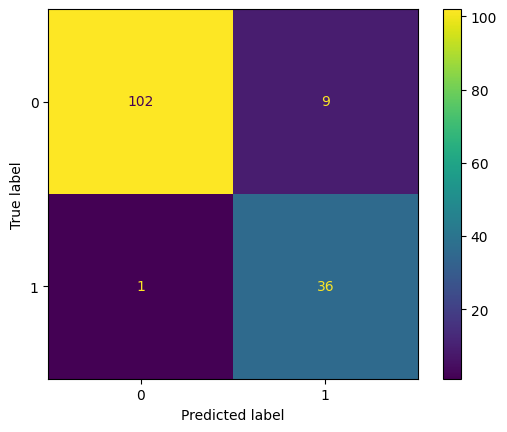

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
m1 = KNeighborsClassifier(n_neighbors=1, metric= 'euclidean')
m1.fit(X_train, y_train)

y_pred = m1.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Menghitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Menampilkan confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

k = 2

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m2 = KNeighborsClassifier(n_neighbors=2, metric= 'euclidean')
m2.fit(X_train, y_train)

y_pred = m2.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[103   8]
 [  2  35]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       111
           1       0.81      0.95      0.88        37

    accuracy                           0.93       148
   macro avg       0.90      0.94      0.91       148
weighted avg       0.94      0.93      0.93       148



k = 3

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m3 = KNeighborsClassifier(n_neighbors=3, metric= 'euclidean')
m3.fit(X_train, y_train)

y_pred = m3.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[101  10]
 [  0  37]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95       111
           1       0.79      1.00      0.88        37

    accuracy                           0.93       148
   macro avg       0.89      0.95      0.92       148
weighted avg       0.95      0.93      0.93       148



k = 4

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m4 = KNeighborsClassifier(n_neighbors=4, metric= 'euclidean')
m4.fit(X_train, y_train)

y_pred = m4.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[104   7]
 [  0  37]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       111
           1       0.84      1.00      0.91        37

    accuracy                           0.95       148
   macro avg       0.92      0.97      0.94       148
weighted avg       0.96      0.95      0.95       148



k = 5

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m5 = KNeighborsClassifier(n_neighbors=5, metric= 'euclidean')
m5.fit(X_train, y_train)

y_pred = m5.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[100  11]
 [  0  37]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95       111
           1       0.77      1.00      0.87        37

    accuracy                           0.93       148
   macro avg       0.89      0.95      0.91       148
weighted avg       0.94      0.93      0.93       148



k = 6

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m6 = KNeighborsClassifier(n_neighbors=6, metric= 'euclidean')
m6.fit(X_train, y_train)

y_pred = m6.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[102   9]
 [  0  37]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       111
           1       0.80      1.00      0.89        37

    accuracy                           0.94       148
   macro avg       0.90      0.96      0.92       148
weighted avg       0.95      0.94      0.94       148



k = 7

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m7 = KNeighborsClassifier(n_neighbors=7, metric= 'euclidean')
m7.fit(X_train, y_train)

y_pred = m7.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[99 12]
 [ 0 37]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94       111
           1       0.76      1.00      0.86        37

    accuracy                           0.92       148
   macro avg       0.88      0.95      0.90       148
weighted avg       0.94      0.92      0.92       148



k = 8

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m8 = KNeighborsClassifier(n_neighbors=8, metric= 'euclidean')
m8.fit(X_train, y_train)

y_pred = m8.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[100  11]
 [  0  37]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95       111
           1       0.77      1.00      0.87        37

    accuracy                           0.93       148
   macro avg       0.89      0.95      0.91       148
weighted avg       0.94      0.93      0.93       148



k = 9

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m9 = KNeighborsClassifier(n_neighbors=9, metric= 'euclidean')
m9.fit(X_train, y_train)

y_pred = m9.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  6]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.78      1.00      0.88        21

    accuracy                           0.92        74
   macro avg       0.89      0.94      0.91        74
weighted avg       0.94      0.92      0.92        74



# Model KNN metrics Manhattan

k = 1

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m10 = KNeighborsClassifier(n_neighbors=1, metric= 'manhattan')
m10.fit(X_train, y_train)

y_pred = m10.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  6]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.78      1.00      0.88        21

    accuracy                           0.92        74
   macro avg       0.89      0.94      0.91        74
weighted avg       0.94      0.92      0.92        74



k = 2

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m11 = KNeighborsClassifier(n_neighbors=2, metric= 'manhattan')
m11.fit(X_train, y_train)

y_pred = m11.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[49  4]
 [ 2 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.83      0.90      0.86        21

    accuracy                           0.92        74
   macro avg       0.89      0.91      0.90        74
weighted avg       0.92      0.92      0.92        74



k = 3

Confusion Matrix:
[[101  10]
 [  0  37]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95       111
           1       0.79      1.00      0.88        37

    accuracy                           0.93       148
   macro avg       0.89      0.95      0.92       148
weighted avg       0.95      0.93      0.93       148



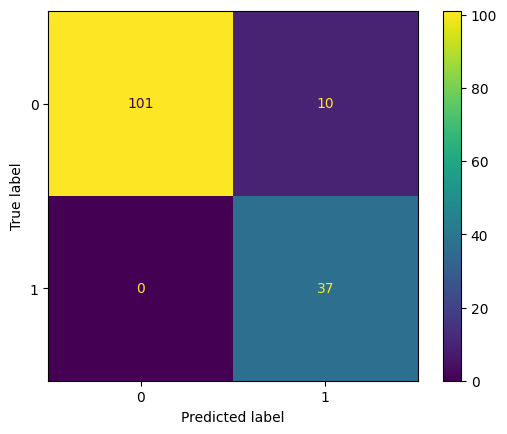

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
m12 = KNeighborsClassifier(n_neighbors=3, metric= 'manhattan')
m12.fit(X_train, y_train)

y_pred = m12.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Menghitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Menampilkan confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

k = 4

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m13 = KNeighborsClassifier(n_neighbors=4, metric= 'manhattan')
m13.fit(X_train, y_train)

y_pred = m13.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[103   8]
 [  0  37]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96       111
           1       0.82      1.00      0.90        37

    accuracy                           0.95       148
   macro avg       0.91      0.96      0.93       148
weighted avg       0.96      0.95      0.95       148



k = 5

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m14 = KNeighborsClassifier(n_neighbors=5, metric= 'manhattan')
m14.fit(X_train, y_train)

y_pred = m14.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  6]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.78      1.00      0.88        21

    accuracy                           0.92        74
   macro avg       0.89      0.94      0.91        74
weighted avg       0.94      0.92      0.92        74



k = 6

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m15 = KNeighborsClassifier(n_neighbors=6, metric= 'manhattan')
m15.fit(X_train, y_train)

y_pred = m15.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[48  5]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        53
           1       0.81      1.00      0.89        21

    accuracy                           0.93        74
   macro avg       0.90      0.95      0.92        74
weighted avg       0.95      0.93      0.93        74



k = 7

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m16 = KNeighborsClassifier(n_neighbors=7, metric= 'manhattan')
m16.fit(X_train, y_train)

y_pred = m16.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[48  5]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        53
           1       0.81      1.00      0.89        21

    accuracy                           0.93        74
   macro avg       0.90      0.95      0.92        74
weighted avg       0.95      0.93      0.93        74



k = 8

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m17 = KNeighborsClassifier(n_neighbors=8, metric= 'manhattan')
m17.fit(X_train, y_train)

y_pred = m17.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[48  5]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        53
           1       0.81      1.00      0.89        21

    accuracy                           0.93        74
   macro avg       0.90      0.95      0.92        74
weighted avg       0.95      0.93      0.93        74



k = 9

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m18 = KNeighborsClassifier(n_neighbors=9, metric= 'manhattan')
m18.fit(X_train, y_train)

y_pred = m18.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  6]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.78      1.00      0.88        21

    accuracy                           0.92        74
   macro avg       0.89      0.94      0.91        74
weighted avg       0.94      0.92      0.92        74



# Model KNN metrics Minkowski, p = 1

k = 1

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m19 = KNeighborsClassifier(n_neighbors=1, metric='minkowski', p=1)
m19.fit(X_train, y_train)

y_pred = m19.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  6]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.78      1.00      0.88        21

    accuracy                           0.92        74
   macro avg       0.89      0.94      0.91        74
weighted avg       0.94      0.92      0.92        74



k = 2

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m20 = KNeighborsClassifier(n_neighbors=2, metric='minkowski', p=1)
m20.fit(X_train, y_train)

y_pred = m20.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[49  4]
 [ 2 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.83      0.90      0.86        21

    accuracy                           0.92        74
   macro avg       0.89      0.91      0.90        74
weighted avg       0.92      0.92      0.92        74



k = 3

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m21 = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=1)
m21.fit(X_train, y_train)

y_pred = m21.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  6]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.78      1.00      0.88        21

    accuracy                           0.92        74
   macro avg       0.89      0.94      0.91        74
weighted avg       0.94      0.92      0.92        74



k = 4

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m22 = KNeighborsClassifier(n_neighbors=4, metric='minkowski', p=1)
m22.fit(X_train, y_train)

y_pred = m22.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[49  4]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        53
           1       0.84      1.00      0.91        21

    accuracy                           0.95        74
   macro avg       0.92      0.96      0.94        74
weighted avg       0.95      0.95      0.95        74



k = 5

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m23 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=1)
m23.fit(X_train, y_train)

y_pred = m23.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  6]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.78      1.00      0.88        21

    accuracy                           0.92        74
   macro avg       0.89      0.94      0.91        74
weighted avg       0.94      0.92      0.92        74



k = 6

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m24 = KNeighborsClassifier(n_neighbors=6, metric='minkowski', p=1)
m24.fit(X_train, y_train)

y_pred = m24.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[48  5]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        53
           1       0.81      1.00      0.89        21

    accuracy                           0.93        74
   macro avg       0.90      0.95      0.92        74
weighted avg       0.95      0.93      0.93        74



k = 7

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m25 = KNeighborsClassifier(n_neighbors=7, metric='minkowski', p=1)
m25.fit(X_train, y_train)

y_pred = m25.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[48  5]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        53
           1       0.81      1.00      0.89        21

    accuracy                           0.93        74
   macro avg       0.90      0.95      0.92        74
weighted avg       0.95      0.93      0.93        74



k = 8

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m26 = KNeighborsClassifier(n_neighbors=8, metric='minkowski', p=1)
m26.fit(X_train, y_train)

y_pred = m26.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[48  5]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        53
           1       0.81      1.00      0.89        21

    accuracy                           0.93        74
   macro avg       0.90      0.95      0.92        74
weighted avg       0.95      0.93      0.93        74



k = 9

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m27 = KNeighborsClassifier(n_neighbors=9, metric='minkowski', p=1)
m27.fit(X_train, y_train)

y_pred = m27.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  6]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.78      1.00      0.88        21

    accuracy                           0.92        74
   macro avg       0.89      0.94      0.91        74
weighted avg       0.94      0.92      0.92        74



# Model KNN metrics Minkowski, p = 2

k = 1

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m28 = KNeighborsClassifier(n_neighbors=1, metric='minkowski', p=2)
m28.fit(X_train, y_train)

y_pred = m28.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[48  5]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        53
           1       0.81      1.00      0.89        21

    accuracy                           0.93        74
   macro avg       0.90      0.95      0.92        74
weighted avg       0.95      0.93      0.93        74



k = 2

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m29 = KNeighborsClassifier(n_neighbors=2, metric='minkowski', p=2)
m29.fit(X_train, y_train)

y_pred = m29.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[49  4]
 [ 2 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.83      0.90      0.86        21

    accuracy                           0.92        74
   macro avg       0.89      0.91      0.90        74
weighted avg       0.92      0.92      0.92        74



k = 3

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m30 = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2)
m30.fit(X_train, y_train)

y_pred = m30.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[48  5]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        53
           1       0.81      1.00      0.89        21

    accuracy                           0.93        74
   macro avg       0.90      0.95      0.92        74
weighted avg       0.95      0.93      0.93        74



k = 4

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m31 = KNeighborsClassifier(n_neighbors=4, metric='minkowski', p=2)
m31.fit(X_train, y_train)

y_pred = m31.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[104   7]
 [  0  37]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       111
           1       0.84      1.00      0.91        37

    accuracy                           0.95       148
   macro avg       0.92      0.97      0.94       148
weighted avg       0.96      0.95      0.95       148



k = 5

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m32 = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
m32.fit(X_train, y_train)

y_pred = m32.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  6]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.78      1.00      0.88        21

    accuracy                           0.92        74
   macro avg       0.89      0.94      0.91        74
weighted avg       0.94      0.92      0.92        74



k = 6

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m33 = KNeighborsClassifier(n_neighbors=6, metric='minkowski', p=2)
m33.fit(X_train, y_train)

y_pred = m33.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[48  5]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        53
           1       0.81      1.00      0.89        21

    accuracy                           0.93        74
   macro avg       0.90      0.95      0.92        74
weighted avg       0.95      0.93      0.93        74



k = 7

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m34 = KNeighborsClassifier(n_neighbors=7, metric='minkowski', p=2)
m34.fit(X_train, y_train)

y_pred = m34.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  6]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.78      1.00      0.88        21

    accuracy                           0.92        74
   macro avg       0.89      0.94      0.91        74
weighted avg       0.94      0.92      0.92        74



k = 8

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m35 = KNeighborsClassifier(n_neighbors=8, metric='minkowski', p=2)
m35.fit(X_train, y_train)

y_pred = m35.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  6]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.78      1.00      0.88        21

    accuracy                           0.92        74
   macro avg       0.89      0.94      0.91        74
weighted avg       0.94      0.92      0.92        74



k = 9

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
m36 = KNeighborsClassifier(n_neighbors=9, metric='minkowski', p=2)
m36.fit(X_train, y_train)

y_pred = m36.predict(X_test)

#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  6]
 [ 0 21]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94        53
           1       0.78      1.00      0.88        21

    accuracy                           0.92        74
   macro avg       0.89      0.94      0.91        74
weighted avg       0.94      0.92      0.92        74



# Ranking urutan jarak euclidean terdekat

In [ ]:
# Hitung jarak antara data uji dan semua data latih
distances, indices = m13.kneighbors(X_test)

# Ambil tiga data terdekat
nearest_neighbors = indices[:1, :9]

# Menampilkan indeks data terdekat
print("Data terdekat untuk setiap sampel dalam data uji:")
print(nearest_neighbors)

Data terdekat untuk setiap sampel dalam data uji:
[[ 721 1035    8  867]]


In [ ]:
# Hitung jarak antara data uji dan semua data latih
distances, indices = m4.kneighbors(X_test)

# Ambil tiga data terdekat
nearest_neighbors = indices[:1, :3]

# Menampilkan indeks data terdekat
print("Data terdekat untuk setiap sampel dalam data uji:")
print(nearest_neighbors)

Data terdekat untuk setiap sampel dalam data uji:
[[ 721 1035  867]]


# Mencari Nilai K Terbaik metrics Euclidean

k =  1 => akurasi =  0.93
k =  2 => akurasi =  0.92
k =  3 => akurasi =  0.93
k =  4 => akurasi =  0.95
k =  5 => akurasi =  0.92
k =  6 => akurasi =  0.93
k =  7 => akurasi =  0.92
k =  8 => akurasi =  0.92
k =  9 => akurasi =  0.92
Best k: 4


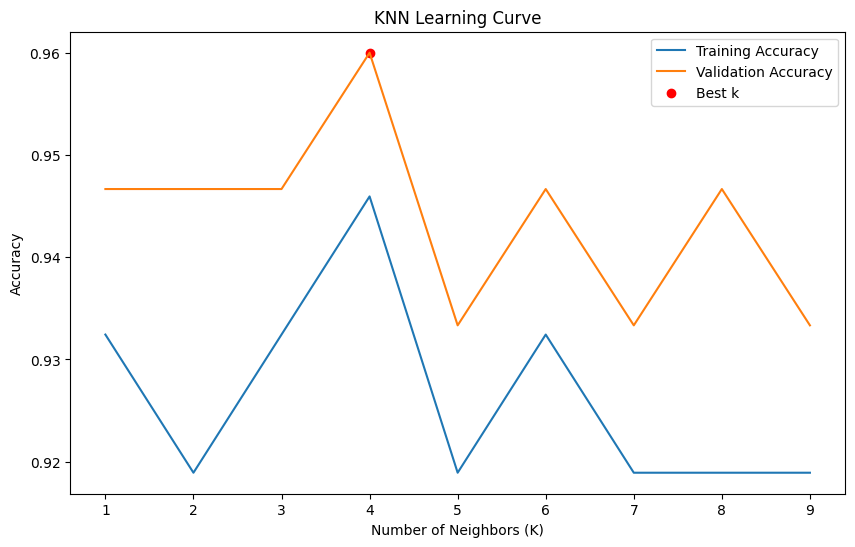

In [ ]:
#mencari nilai K terbaik
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracies = []
val_accuracy = []

for k in range(1,10):
  knn_model = KNeighborsClassifier(n_neighbors = k, metric='euclidean')
  knn_model.fit(X_train, y_train)
  y_pred_test = knn_model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred_test)
  accuracies.append(accuracy)
  val_accuracy.append(knn_model.score(X_val, y_val))

for k in range(1,10):
  print("k = ", k, "=> akurasi = ", np.round(accuracies[k-1], 2))

best_k = val_accuracy.index(max(val_accuracy)) + 1
print("Best k:", best_k)

best_k = val_accuracy.index(max(val_accuracy)) + 1

plt.figure(figsize=(10, 6))
plt.plot(range(1,10), accuracies, label='Training Accuracy')
plt.plot(range(1, 10), val_accuracy, label='Validation Accuracy')
plt.scatter(best_k, max(val_accuracy), color='red', label='Best k')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Learning Curve')
plt.legend()
plt.show()

# Mencari Nilai K Terbaik metrics Manhattan

k =  1 => akurasi =  0.93
k =  2 => akurasi =  0.93
k =  3 => akurasi =  0.93
k =  4 => akurasi =  0.95
k =  5 => akurasi =  0.92
k =  6 => akurasi =  0.95
k =  7 => akurasi =  0.92
k =  8 => akurasi =  0.93
k =  9 => akurasi =  0.91
Best k: 4


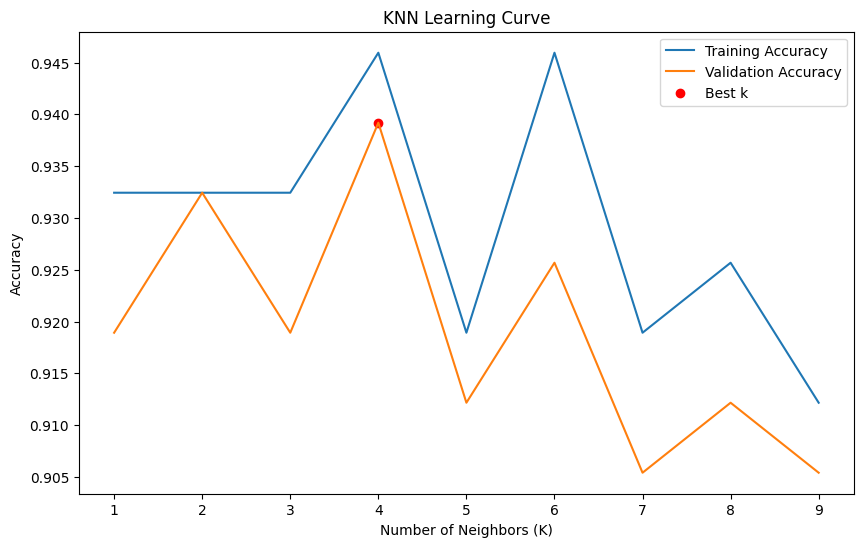

In [ ]:
#mencari nilai K terbaik
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracies = []
val_accuracy = []

for k in range(1,10):
  knn_model = KNeighborsClassifier(n_neighbors = k, metric='manhattan')
  knn_model.fit(X_train, y_train)
  y_pred_test = knn_model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred_test)
  accuracies.append(accuracy)
  val_accuracy.append(knn_model.score(X_val, y_val))

for k in range(1,10):
  print("k = ", k, "=> akurasi = ", np.round(accuracies[k-1], 2))

best_k = val_accuracy.index(max(val_accuracy)) + 1
print("Best k:", best_k)

best_k = val_accuracy.index(max(val_accuracy)) + 1

plt.figure(figsize=(10, 6))
plt.plot(range(1,10), accuracies, label='Training Accuracy')
plt.plot(range(1, 10), val_accuracy, label='Validation Accuracy')
plt.scatter(best_k, max(val_accuracy), color='red', label='Best k')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Learning Curve')
plt.legend()
plt.show()

# Mencari Nilai K Terbaik metrics Minkowski p = 1

k =  1 => akurasi =  0.92
k =  2 => akurasi =  0.93
k =  3 => akurasi =  0.93
k =  4 => akurasi =  0.95
k =  5 => akurasi =  0.92
k =  6 => akurasi =  0.94
k =  7 => akurasi =  0.92
k =  8 => akurasi =  0.93
k =  9 => akurasi =  0.92
Best k: 3


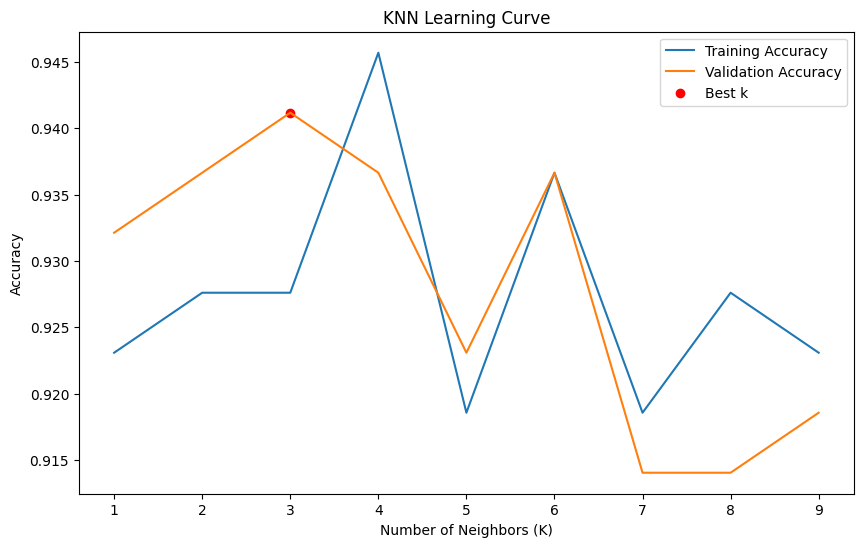

In [ ]:
#mencari nilai K terbaik
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracies = []
val_accuracy = []

for k in range(1,10):
  knn_model = KNeighborsClassifier(n_neighbors = k, metric='minkowski', p=1)
  knn_model.fit(X_train, y_train)
  y_pred_test = knn_model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred_test)
  accuracies.append(accuracy)
  val_accuracy.append(knn_model.score(X_val, y_val))

for k in range(1,10):
  print("k = ", k, "=> akurasi = ", np.round(accuracies[k-1], 2))

best_k = val_accuracy.index(max(val_accuracy)) + 1
print("Best k:", best_k)

best_k = val_accuracy.index(max(val_accuracy)) + 1

plt.figure(figsize=(10, 6))
plt.plot(range(1,10), accuracies, label='Training Accuracy')
plt.plot(range(1, 10), val_accuracy, label='Validation Accuracy')
plt.scatter(best_k, max(val_accuracy), color='red', label='Best k')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Learning Curve')
plt.legend()
plt.show()

# Mencari Nilai K Terbaik metrics Minkowski p = 2

k =  1 => akurasi =  0.93
k =  2 => akurasi =  0.94
k =  3 => akurasi =  0.93
k =  4 => akurasi =  0.94
k =  5 => akurasi =  0.92
k =  6 => akurasi =  0.94
k =  7 => akurasi =  0.92
k =  8 => akurasi =  0.93
k =  9 => akurasi =  0.91
Best k: 2


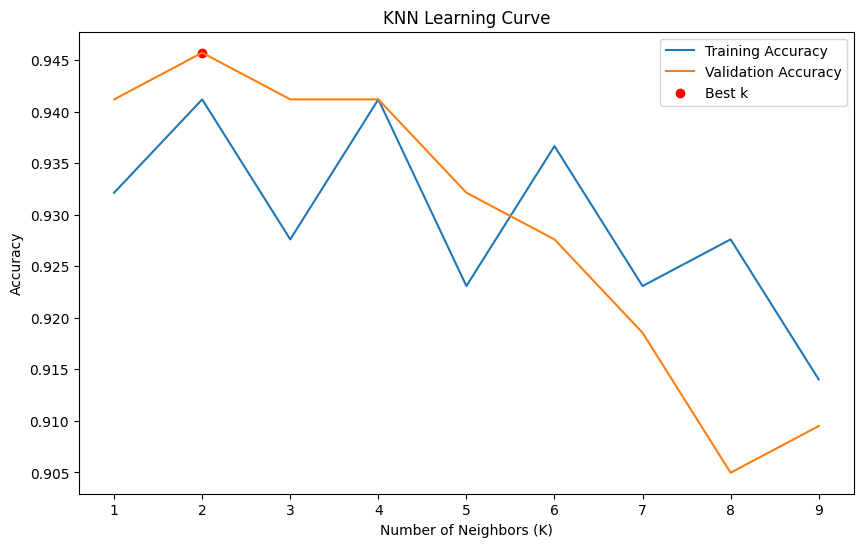

In [ ]:
#mencari nilai K terbaik
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

accuracies = []
val_accuracy = []

for k in range(1,10):
  knn_model = KNeighborsClassifier(n_neighbors = k, metric='minkowski', p=2)
  knn_model.fit(X_train, y_train)
  y_pred_test = knn_model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred_test)
  accuracies.append(accuracy)
  val_accuracy.append(knn_model.score(X_val, y_val))

for k in range(1,10):
  print("k = ", k, "=> akurasi = ", np.round(accuracies[k-1], 2))

best_k = val_accuracy.index(max(val_accuracy)) + 1
print("Best k:", best_k)

best_k = val_accuracy.index(max(val_accuracy)) + 1

plt.figure(figsize=(10, 6))
plt.plot(range(1,10), accuracies, label='Training Accuracy')
plt.plot(range(1, 10), val_accuracy, label='Validation Accuracy')
plt.scatter(best_k, max(val_accuracy), color='red', label='Best k')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Learning Curve')
plt.legend()
plt.show()

# Prediksi model KNN k = 2, Euclidean

In [ ]:
#prediksi
print(m13.predict([[35, 93, 2.8]]))


[0]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


# Export Model KNN

In [ ]:
import pickle

# save the soil classification model as a pickle file
model_pkl_file = "model.pkl"

with open(model_pkl_file, 'wb') as file:
    pickle.dump(m2, file)

In [ ]:
import pickle

# Load model dari file .pkl
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Input data untuk prediksi (air temperature, soil moisture, soil ph)
input_data = [[28, 29, 5.1]]  # Contoh data input

# Lakukan prediksi menggunakan model
prediction = loaded_model.predict(input_data)

print("Hasil prediksi:",prediction)

Hasil prediksi: [0]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
